# A true planet

What does a backtrack model comparison look like when a candidate is a real, co-moving planet? 

We can explore this (happy) case with observations of HD 135344 Ab from [Stolker et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025A%26A...700A..21S/abstract). In that work, it was important to quantify the difference in goodness of fit between a background track and an orbit fit. 

The orbit fitting package `orbitize!` isn't a requirement for `backtracks`, so you'll need to install it to complete this particular tutorial. Then, we can construct a nice figure to illustrate our argument in favor of one hypothesis versus the other.

## Initialization

In [1]:
# start by importing the System object from backtracks, again:
from backtracks import System

We'll gather our observations:

In [2]:
!wget https://github.com/wbalmer/backtracks/raw/refs/heads/main/tests/hd135344Ab_orbitizelike.csv

--2026-03-31 16:33:23--  https://github.com/wbalmer/backtracks/raw/refs/heads/main/tests/hd135344Ab_orbitizelike.csv
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-31 16:33:23 ERROR 404: Not Found.



Then, we'll set up our System object:

In [3]:
track = System(target_name="HD135344A",
               candidate_file="hd135344Ab_orbitizelike.csv",
               nearby_window=0.5,
               fileprefix='./')

[BACKTRACKS INFO]: Examining object = 1 in input file.
[BACKTRACKS INFO]: Resolved the target star 'HD135344A' in Simbad!
[BACKTRACKS INFO]: Resolved target's Gaia ID from Simbad, Gaia DR3 6199395656645840384
INFO: Query finished. [astroquery.utils.tap.core]
[BACKTRACKS INFO]: gathered Gaia DR3 data for HD135344A
   * Gaia source ID = 6199395656645840384
   * Reference epoch = 2016.0
   * RA = 228.9538 deg
   * Dec = -37.1489 deg
   * PM RA = -18.74 mas/yr
   * PM Dec = -24.01 mas/yr
   * Parallax = 7.41 mas
   * RV = 29.31 km/s
INFO: Query finished. [astroquery.utils.tap.core]
[BACKTRACKS INFO]: gathered 10970 Gaia objects from the 0.5 sq. deg. nearby HD135344A
[BACKTRACKS INFO]: Finished nearby background gaia statistics
[BACKTRACKS INFO]: Queried distance prior parameters, L=3927.31, alpha=1.31, beta=0.62
[BACKTRACKS INFO]: Estimating candidate position if stationary in RA,Dec @ 2016.0 from observation #0
[BACKTRACKS INFO]: Opened ephemeris file


## Stationary, infinite distance background track

[BACKTRACKS INFO]: Generating Stationary plot
[BACKTRACKS INFO]: Stationary track reduced chi squared is 43022061.12
[BACKTRACKS INFO]: Stationary plot saved to ./


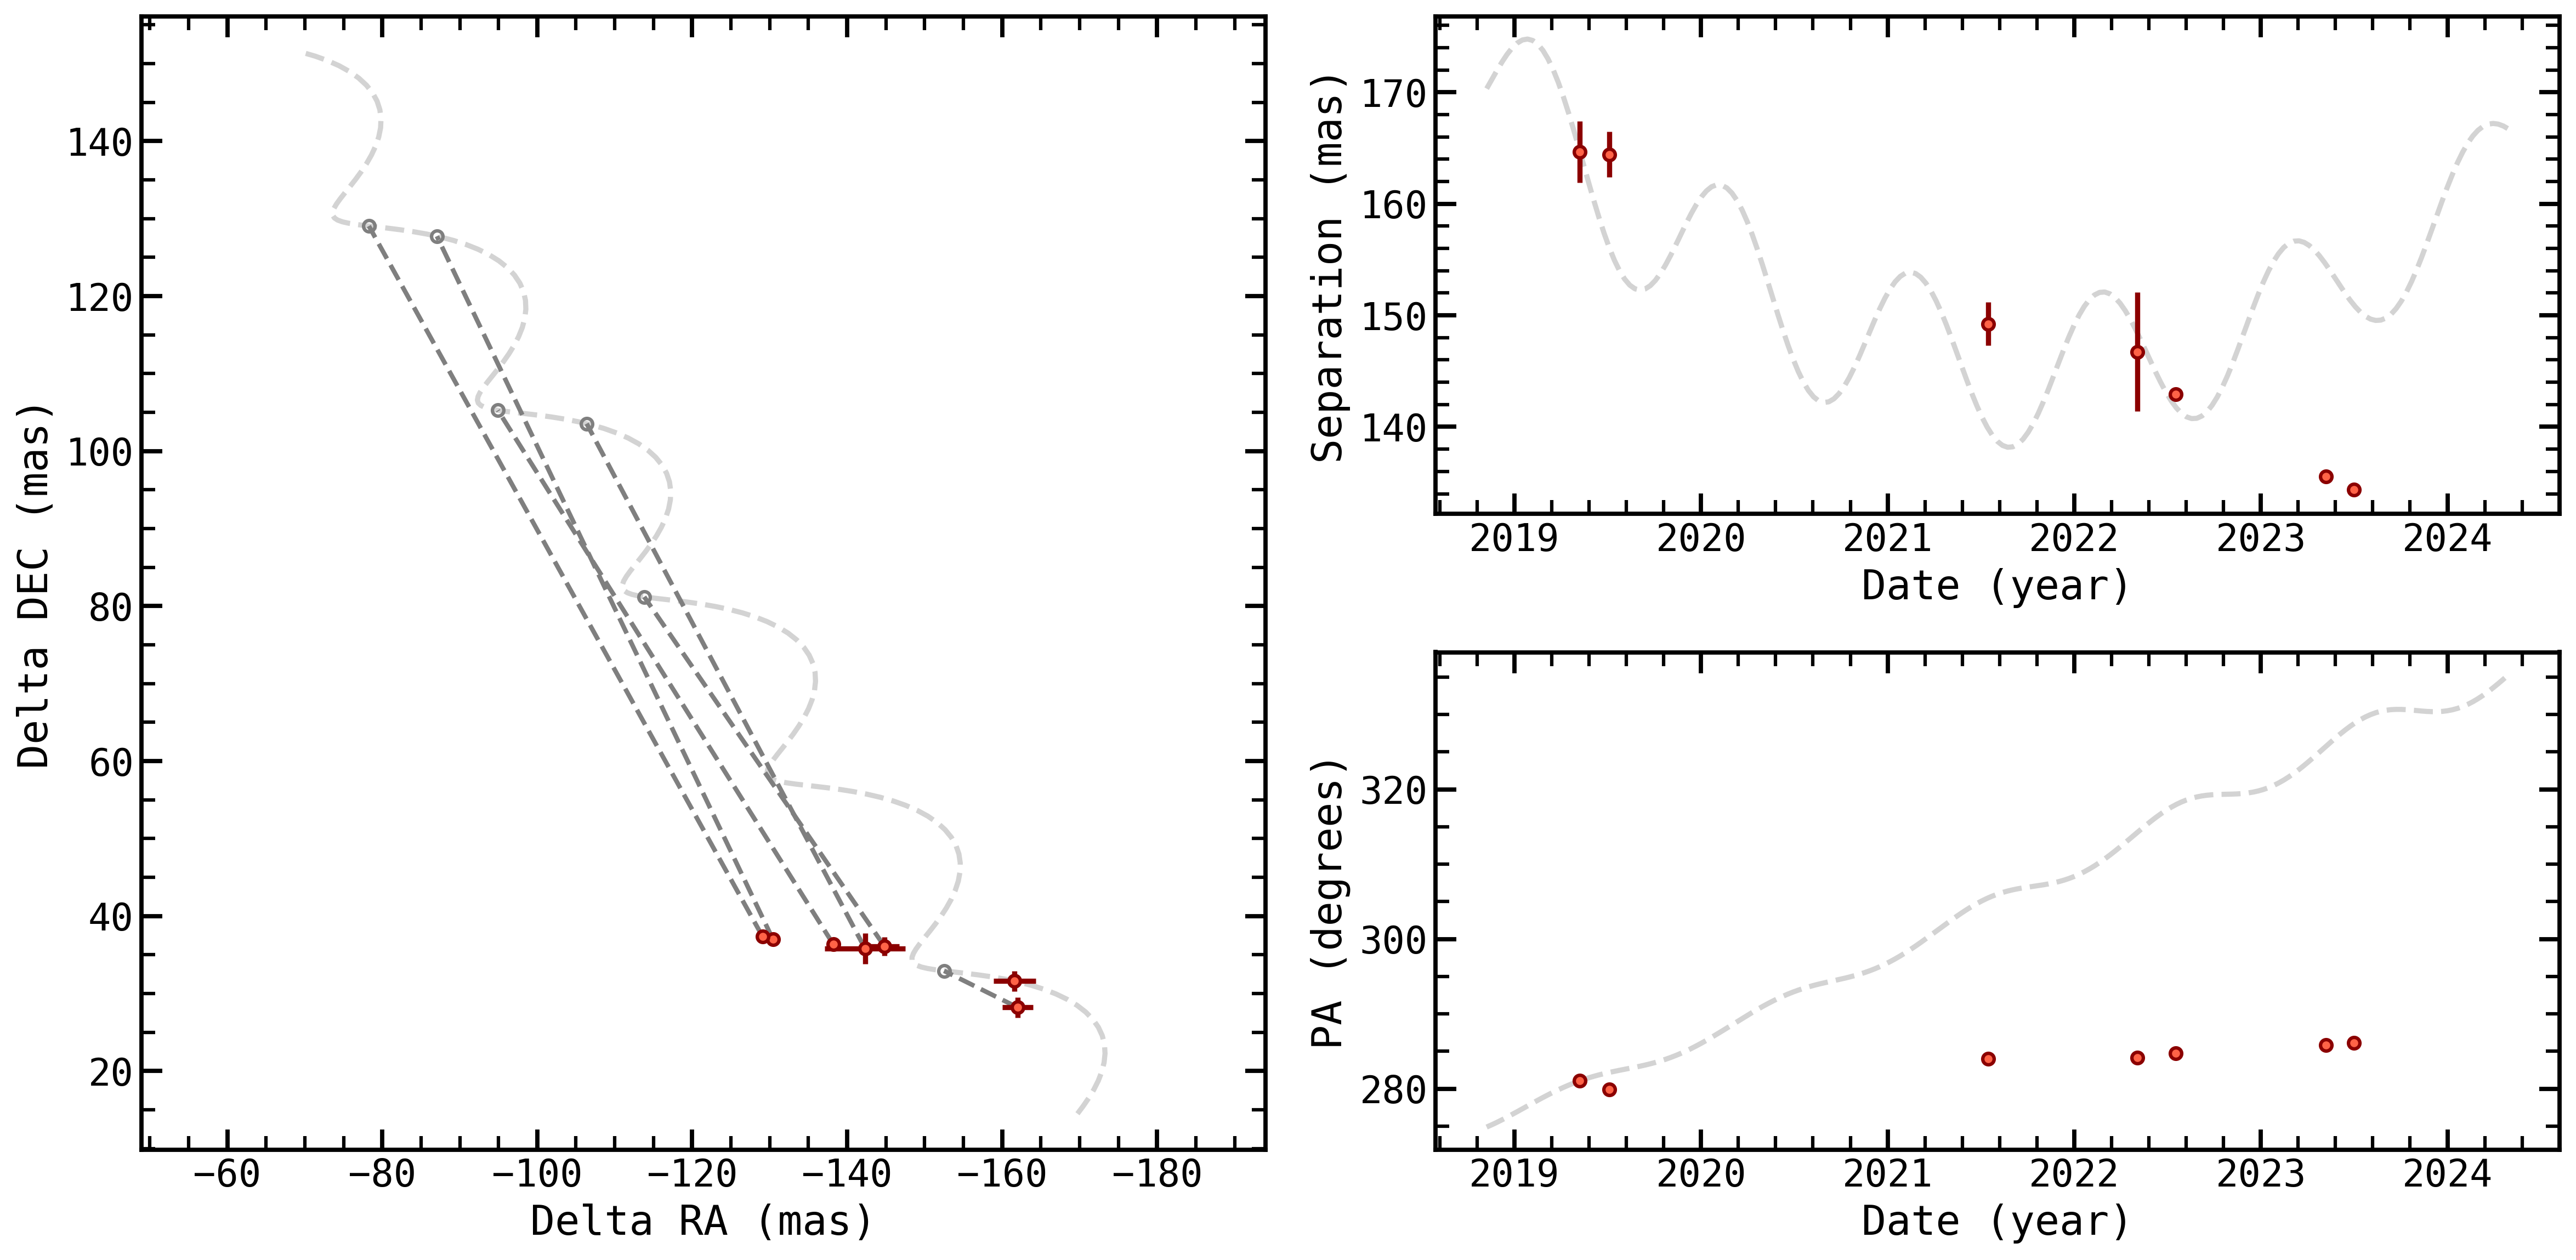

In [4]:
fig_stationary = track.generate_stationary_plot(days_backward=0.5*365.,
                                                days_forward=5*365,
                                                step_size=10.,
                                                filepost='.png')

The stationary track doesn't agree with the data at all, but we could imagine a moving track that could reproduce the same direction of the source's motion, right?

In [5]:
import multiprocessing as mp
results = track.fit(dlogz=1e-2, npool=mp.cpu_count(), 
                    dynamic=False, nlive=100,
                    mpi_pool=False, 
                    resume=False, 
                    sample_method='rslice')

[BACKTRACKS INFO]: Beginning sampling


iter: 10063 | +100 | bound: 341 | nc: 1 | ncall: 802380 | eff(%):  1.267 | loglstar:   -inf < -15.903 <    inf | logz: -111.420 +/-  0.957 | dlogz:  0.000 >  0.010                                   

[BACKTRACKS INFO]: Stationary track reduced chi squared is 43022061.12
[BACKTRACKS INFO]: Median track reduced chi squared is 9.54


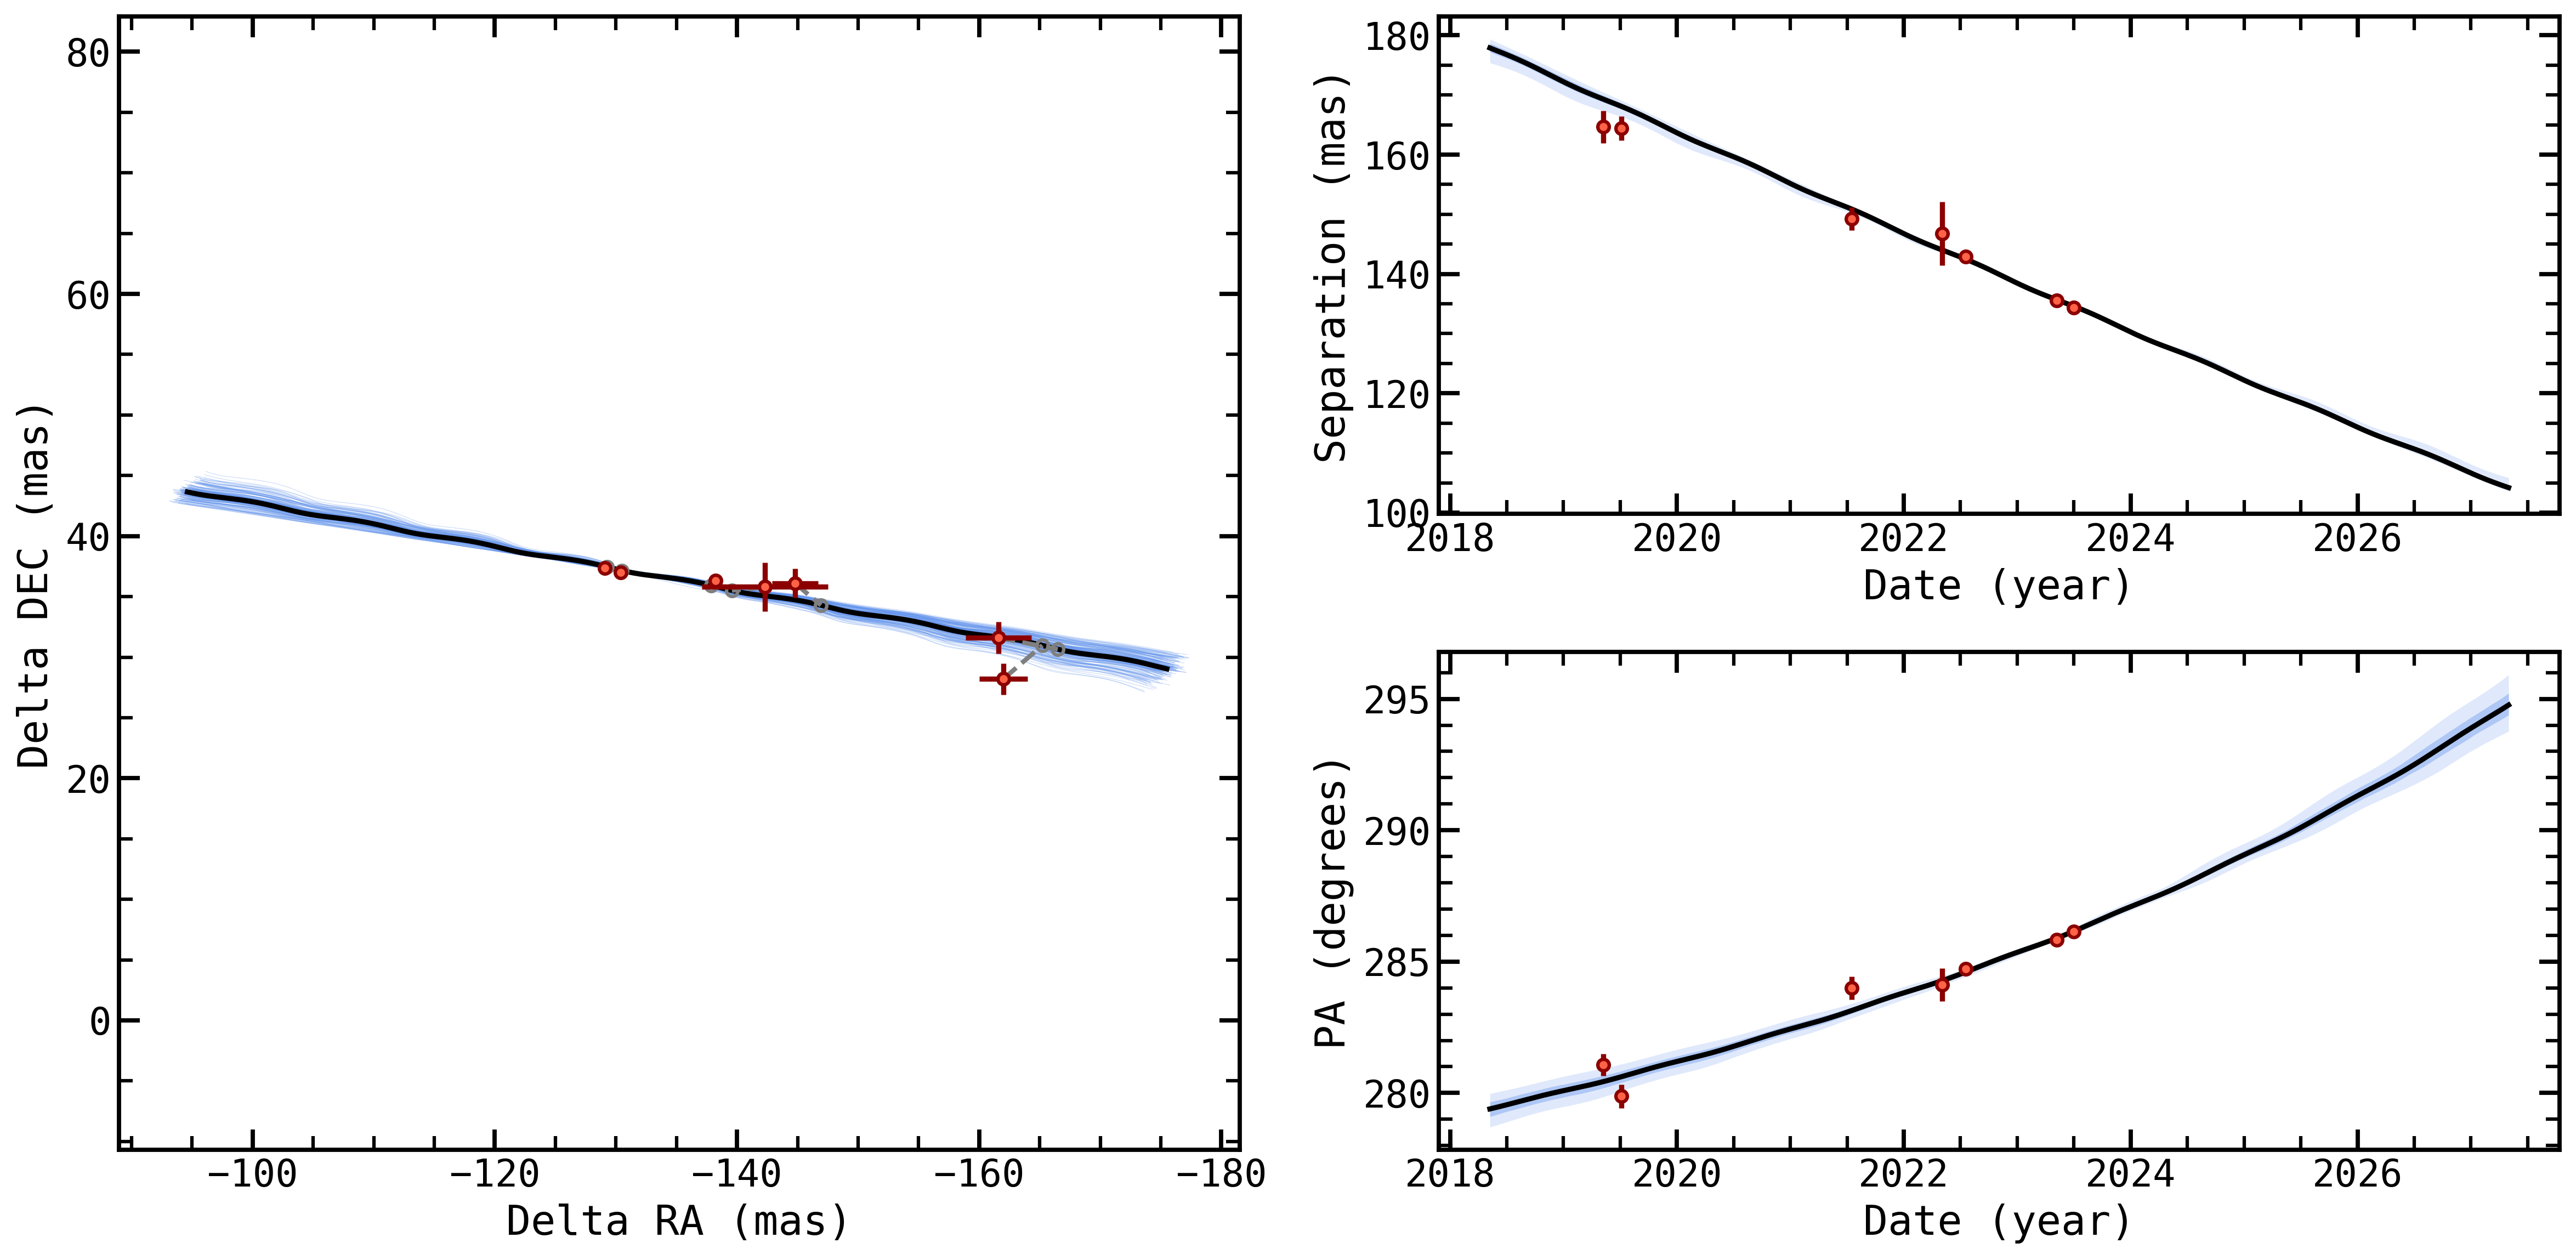

In [6]:
# plot up only the trackplot to show the results
from backtracks.plotting import trackplot
from astropy.time import Time
track_plot = trackplot(track,
                   ref_epoch = Time(track.ref_epoch, format='jd').jd,
                   days_backward=1.*365.,
                   days_forward=8.*365.,
                   step_size=10., # we can tune this down or up to slow/speed up the rendering
                   plot_radec=False,
                   plot_stationary=False,
                   fileprefix='./',
                   filepost='.png'
                  )

The inferred motion is effectively linear (there's no helical component to this best fitting track), which means that the parallax of the candidate and the parallax of are effectively the same. That implies common parallax (as well as common proper motion). Let's fit an orbit and see if that orbit fit can do a better job than `backtracks`.

## Fit an orbit with OFTI

In [11]:
import orbitize
import orbitize.driver
from orbitize import priors

import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from backtracks.utils import radecdists, utc2tt

In [8]:
myDriver = orbitize.driver.Driver("hd135344Ab_orbitizelike.csv", # path to data file
                                  'OFTI', # name of algorithm for orbit-fitting
                                  1, # number of secondary bodies in system
                                  2.2, # total mass [M_sun]
                                  track.paro, # total parallax of system [mas]
                                  mass_err=0.2, # mass error [M_sun]
                                  plx_err=track.mu_par) # parallax error [mas]
s = myDriver.sampler

Converting ra/dec data points in data_table to sep/pa. Original data are stored in input_table.


In [9]:
orbits = s.run_sampler(int(1e4))
myResults = s.results

/Users/wbalmer/miniconda3/envs/bt-pytest/lib/python3.12/site-packages/orbitize/plot.py:1059: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/Users/wbalmer/miniconda3/envs/bt-pytest/lib/python3.12/site-packages/orbitize/plot.py:1059: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


(500.0, -500.0)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<Figure size 4200x1800 with 0 Axes>

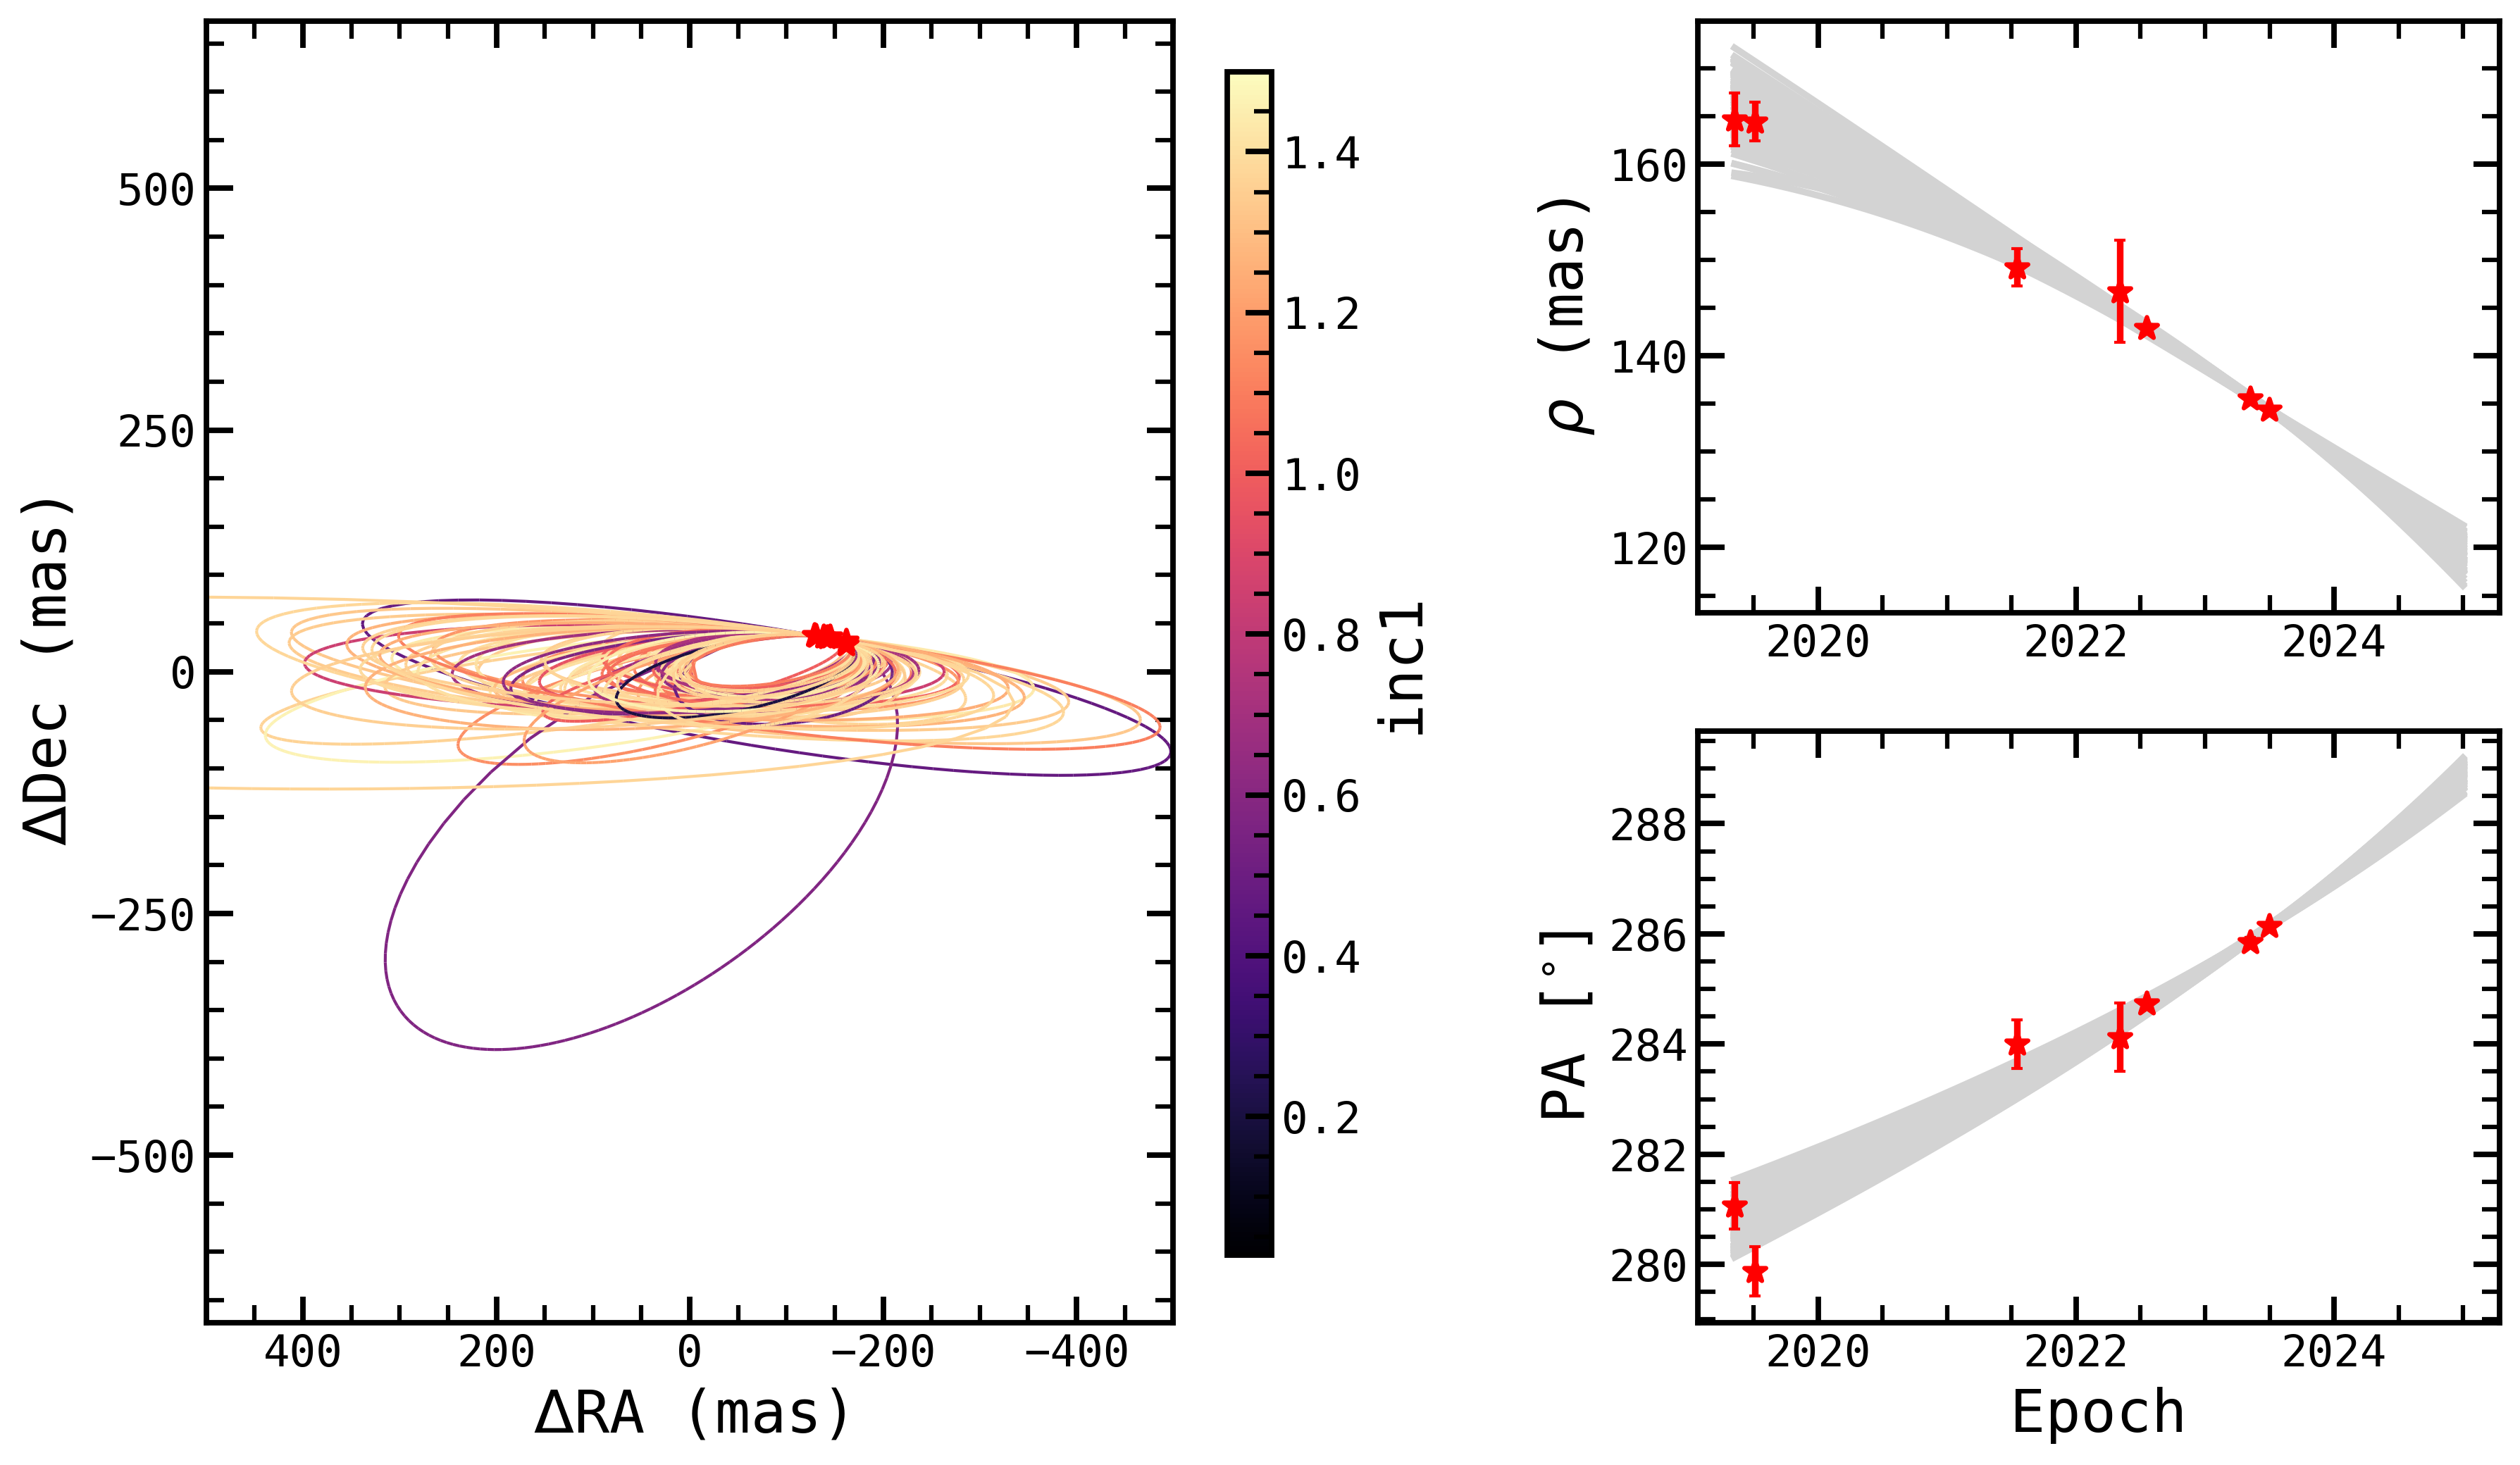

In [12]:
# orbit plot
epochs = myDriver.system.data_table['epoch']
orbit_figure = myResults.plot_orbits(
    start_mjd=epochs[0], # Minimum MJD for colorbar (here we choose first data epoch)
    cmap=plt.cm.magma,
    cbar_param='inc1'
)
radec_ax = orbit_figure.axes[0]
radec_ax.set_ylim(-500,500)
radec_ax.set_xlim(500,-500)

In [13]:
from orbitize.lnlike import chi2_lnlike
from orbitize.kepler import calc_orbit

In [14]:
median_orbit_elements = np.median(myResults.post, axis=0)
orbit_ras, orbit_decs, _ = calc_orbit(Time(track.epochs, format="jd").mjd,
                                      median_orbit_elements[0],
                                      median_orbit_elements[1],
                                      median_orbit_elements[2],
                                      median_orbit_elements[3],
                                      median_orbit_elements[4],
                                      median_orbit_elements[5],
                                      median_orbit_elements[6],
                                      median_orbit_elements[7],
                                      )

In [15]:
lnlike_chi2_orbits = chi2_lnlike(np.array([track.ras, track.decs]).T, # data
            np.array([track.raserr, track.decserr]).T, # errors
            track.rho, # correlations
            np.array([orbit_ras, orbit_decs]).T, # model
            jitter=np.zeros_like(np.array([orbit_ras, orbit_decs]).T),
            seppa_indices=[],
)

In [16]:
orbit_norm_term = orbitize.lnlike.chi2_norm_term(np.array([track.raserr, track.decserr]).T, track.rho)

In [17]:
orbit_reduced_chi2 = np.log(np.sum(lnlike_chi2_orbits)/orbit_norm_term)/((2*(len(track.epochs)-1))-(len(median_orbit_elements)))

print(f"The median orbit has a reduced chi squared of {orbit_reduced_chi2}, compared to the best fit moving background object track, with a reduced chi2 quared of {track.median_chi2_red}")

The median orbit has a reduced chi squared of 3.168662563629823, compared to the best fit moving background object track, with a reduced chi2 quared of 9.540865923818526


The orbit fit, which allows for curvature between the first and last measurements, produces a much better goodness of fit statistic than even our most pathological backtrack (which can only fudge linear motion by making the parallax of the candidate effectively the parallax of the host star). So, we've proved that this candidate source has orbital motion! It must therefore be a new planet!

## Recreate a classic plot

We now have all the tools we need to recreate some classic plots from papers past. In particular, many Gemini Planet Imager collaboration papers have a plot that compares possible orbits to background tracks in separation and position angle. Let's create something similar, except in R.A. and Decl.

In [18]:
n = 100
projected_epochs = np.arange(Time('2019-01-01').jd, Time('2025-01-01').jd, 10)
projected_epochs_tt = utc2tt(projected_epochs)
projected_epochs_mjd = Time(projected_epochs, format="jd").mjd

rand_idxs = np.random.choice(myResults.post.shape[0], size=n, replace=False)
elements = myResults.post[rand_idxs]

ra_orbits, dec_orbits, _ = calc_orbit(projected_epochs_mjd, elements[:,0], elements[:,1], elements[:,2], elements[:,3], elements[:,4], elements[:,5], elements[:,6], elements[:,7])

# Create 1 sigma and 3 sigma percentiles for envelopes of orbits
ra_orbits_quant = np.percentile(ra_orbits, [0.13, 16.0, 84.0, 99.87], axis=1)
dec_orbits_quant = np.percentile(dec_orbits, [0.13, 16.0, 84.0, 99.87], axis=1)

In [19]:
ra_dist = np.random.normal(loc=track.rao, scale=np.sqrt(np.diag(track.host_cov))[0], size=n)
de_dist = np.random.normal(loc=track.deco, scale=np.sqrt(np.diag(track.host_cov))[1], size=n)
plx_dist = np.random.normal(loc=track.paro, scale=np.sqrt(np.diag(track.host_cov))[4], size=n)
pmra_dist = np.random.normal(loc=track.pmrao, scale=np.sqrt(np.diag(track.host_cov))[2], size=n)
pmde_dist = np.random.normal(loc=track.pmdeco, scale=np.sqrt(np.diag(track.host_cov))[3], size=n)

In [20]:
stat_param_dist = np.ones((len(track.stationary_params), n))
stat_param_dist[0,:] *= track.stationary_params[0] # best fit stationary ra
stat_param_dist[1,:] *= track.stationary_params[1] # best fit stationary dec
stat_param_dist[2,:] *= track.stationary_params[2] # dummy stationary plx = 0
stat_param_dist[3,:] *= track.stationary_params[3] # dummy stationary plx = 0
stat_param_dist[4,:] *= track.stationary_params[4] # dummy stationary plx = 0
stat_param_dist[10,:] *= track.stationary_params[10] # host rvs

stat_param_dist[5,:] = ra_dist
stat_param_dist[6,:] = de_dist
stat_param_dist[7,:] = pmra_dist
stat_param_dist[8,:] = pmde_dist
stat_param_dist[9,:] = plx_dist

In [21]:
# now, we'll loop the call the System.radecdists function
ras = np.zeros((n, len(projected_epochs_tt)))
decs = np.zeros((n, len(projected_epochs_tt)))
for i in range(n):
    ras_i, decs_i = radecdists(track, projected_epochs_tt, stat_param_dist[:,i])
    ras[i] += ras_i
    decs[i] += decs_i

In [22]:
# Create 1 sigma and 3 sigma percentiles for envelopes of tracks
ras_quant = np.percentile(ras, [0.13, 16.0, 84.0, 99.87], axis=0)
decs_quant = np.percentile(decs, [0.13, 16.0, 84.0, 99.87], axis=0)

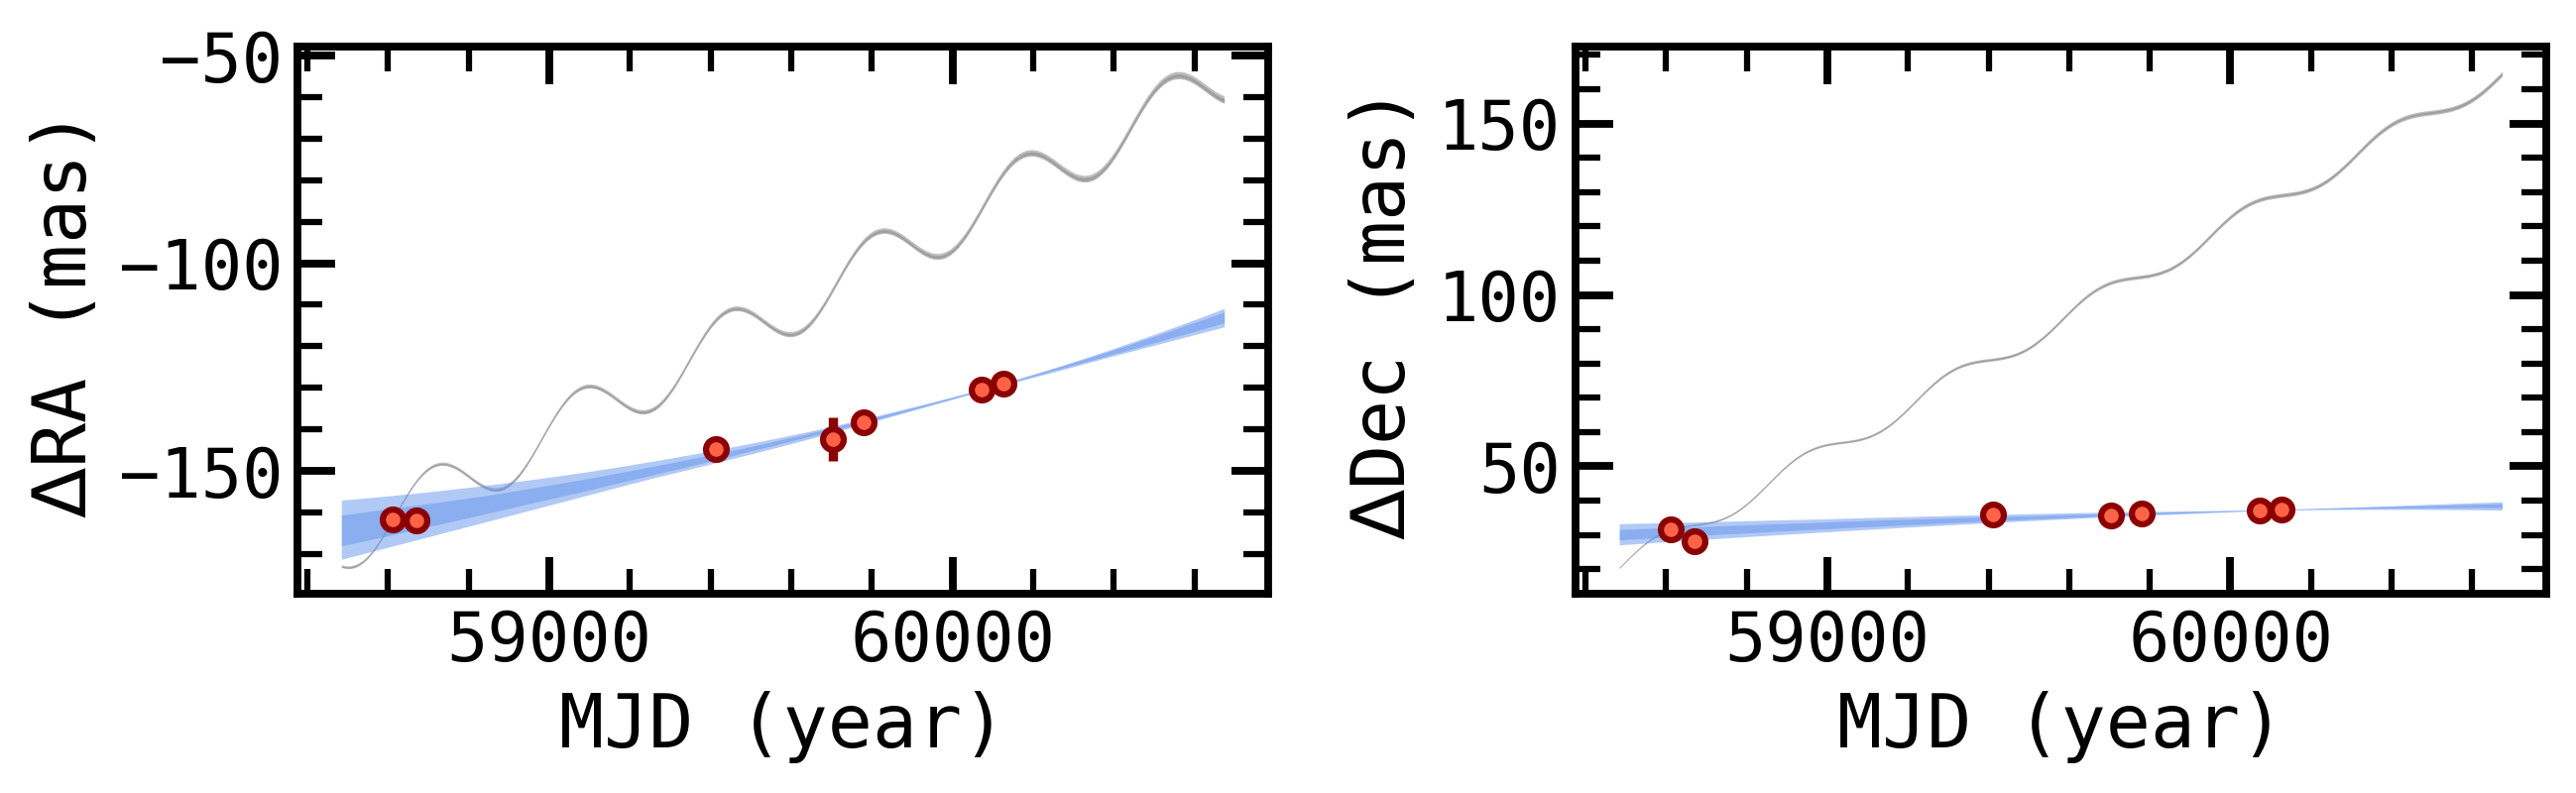

In [23]:
# and we'll plot the results to prove this works
fig, axs = plt.subplots(1, 2, figsize=(9,3))

# plot envelope of tracks
axs[0].fill_between(projected_epochs_mjd, y1=ras_quant[0, ], y2=ras_quant[3, ], color='grey', alpha=0.5, lw=0.)
axs[1].fill_between(projected_epochs_mjd, y1=decs_quant[0, ], y2=decs_quant[3, ], color='grey', alpha=0.5, lw=0.)

axs[0].fill_between(projected_epochs_mjd, y1=ras_quant[1, ], y2=ras_quant[2, ], color='grey', alpha=0.5, lw=0.)
axs[1].fill_between(projected_epochs_mjd, y1=decs_quant[1, ], y2=decs_quant[2, ], color='grey', alpha=0.5, lw=0.)

# plot envelope of orbits
axs[0].fill_between(projected_epochs_mjd, y1=ra_orbits_quant[0, ], y2=ra_orbits_quant[3, ], color='cornflowerblue', alpha=0.5, lw=0.)
axs[1].fill_between(projected_epochs_mjd, y1=dec_orbits_quant[0, ], y2=dec_orbits_quant[3, ], color='cornflowerblue', alpha=0.5, lw=0.)

axs[0].fill_between(projected_epochs_mjd, y1=ra_orbits_quant[1, ], y2=ra_orbits_quant[2, ], color='cornflowerblue', alpha=0.5, lw=0.)
axs[1].fill_between(projected_epochs_mjd, y1=dec_orbits_quant[1, ], y2=dec_orbits_quant[2, ], color='cornflowerblue', alpha=0.5, lw=0.)

# and we can throw up some data
axs[0].errorbar(Time(track.epochs, format="jd").mjd, track.ras, yerr=track.raserr,
                color="tomato", ecolor='darkred', linestyle="none",
                marker='o', ms=5., mew=1.5, mec='darkred')

axs[1].errorbar(Time(track.epochs, format="jd").mjd, track.decs, yerr=track.decserr,
                color="tomato", ecolor='darkred', linestyle="none",
                marker='o', ms=5., mew=1.5, mec='darkred')

# and label the axes
axs[0].set_xlabel('MJD (year)')
axs[0].set_ylabel(r'$\Delta$RA (mas)')
axs[1].set_xlabel('MJD (year)')
axs[1].set_ylabel(r'$\Delta$Dec (mas)')

fig.tight_layout()

plt.show()